In [1]:
%pip install seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree  import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid", palette = 'Set2')
RANDOM_STATE=42

model_col = ['person_age', 'person_gender', 'person_education', 'person_state',
       'person_income', 'person_emp_status', 'person_emp_exp',
       'person_home_ownership', 'help_debt_amount',
       'loan_amnt', 'loan_intent', 'loan_term_months', 'loan_int_rate',
       'loan_percent_income', 'credit_history_length', 'credit_score',
       'previous_loan_defaults_on_file','flag_income_loan_mismatch', 'flag_young_high_loan'
        ]

In [3]:
datam=pd.read_csv('modelling_data.csv')
datam

,person_age,person_gender,person_education,person_state,person_income,person_emp_status,person_emp_exp,person_home_ownership,help_debt_amount,loan_amnt,loan_intent,loan_term_months,loan_int_rate,loan_percent_income,credit_history_length,credit_score,previous_loan_defaults_on_file,loan_status,flag_income_loan_mismatch,flag_young_high_loan
0,39,MALE,HIGH SCHOOL,QLD,62994,FULL-TIME,9,OWN,0,7600,DEBT_CONSOLIDATION,84,8.94,0.120646,17,843,NO,1,0,0
1,25,MALE,CERTIFICATE/DIPLOMA,SA,77107,FULL-TIME,5,MORTGAGE,0,14100,DEBT_CONSOLIDATION,36,12.25,0.182863,6,734,NO,0,0,0
2,45,FEMALE,CERTIFICATE/DIPLOMA,WA,30752,PART-TIME,21,RENT,0,36000,VEHICLE,12,18.35,1.170656,24,732,NO,0,1,0
3,38,MALE,BACHELOR,VIC,84232,FULL-TIME,5,FAMILY,7185,53000,PERSONAL,60,11.10,0.629215,16,969,NO,1,1,0
4,75,MALE,BACHELOR,NSW,141352,PART-TIME,1,MORTGAGE,0,17000,HOME_IMPROVEMENT,60,23.63,0.120267,57,845,YES,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44883,37,FEMALE,BACHELOR,NSW,69481,FULL-TIME,5,RENT,0,13600,DEBT_CONSOLIDATION,24,13.66,0.195737,16,733,NO,1,0,0
44884,26,MALE,BACHELOR,ACT,63023,CASUAL,8,RENT,105721,56400,DEBT_CONSOLIDATION,24,18.97,0.894911,8,689,YES,0,1,0
44885,61,FEMALE,BACHELOR,NSW,84329,CASUAL,5,RENT,0,15100,HOME_IMPROVEMENT,72,13.09,0.179061,41,572,NO,1,0,0
44886,37,FEMALE,CERTIFICATE/DIPLOMA,SA,57234,FULL-TIME,5,FAMILY,0,54300,HOME_IMPROVEMENT,36,16.71,0.948737,18,568,NO,0,1,0


## Dataset overview:

In [4]:
datam.describe().round(2)

,person_age,person_income,person_emp_exp,help_debt_amount,loan_amnt,loan_term_months,loan_int_rate,loan_percent_income,credit_history_length,credit_score,loan_status,flag_income_loan_mismatch,flag_young_high_loan
count,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00,44888.00
mean,45.21,69673.07,7.90,5624.89,19899.10,44.19,13.87,0.38,25.22,748.89,0.52,0.23,0.00
std,12.97,41047.76,5.07,11863.58,13530.71,16.95,3.48,0.36,13.04,158.16,0.50,0.42,0.03
min,19.00,20000.00,0.00,0.00,2000.00,12.00,5.50,0.01,0.00,58.00,0.00,0.00,0.00
25%,35.00,41345.00,4.00,0.00,10400.00,36.00,11.49,0.15,15.00,641.75,0.00,0.00,0.00
50%,43.00,60042.50,7.00,0.00,16200.00,36.00,13.86,0.27,23.00,750.00,1.00,0.00,0.00
75%,53.00,86725.25,11.00,6552.00,25300.00,60.00,16.23,0.48,33.00,858.00,1.00,0.00,0.00
max,75.00,450000.00,42.00,120000.00,75000.00,84.00,25.00,3.75,57.00,1198.00,1.00,1.00,1.00


In [5]:
datam.shape

(44888, 20)

## EDA

In [6]:
datam['loan_status'].value_counts()

loan_status
1    23457
0    21431
Name: count, dtype: int64

In [7]:
datam['loan_status'].value_counts(normalize=True)*100

loan_status
1    52.256728
0    47.743272
Name: proportion, dtype: float64

<Axes: xlabel='loan_status', ylabel='count'>

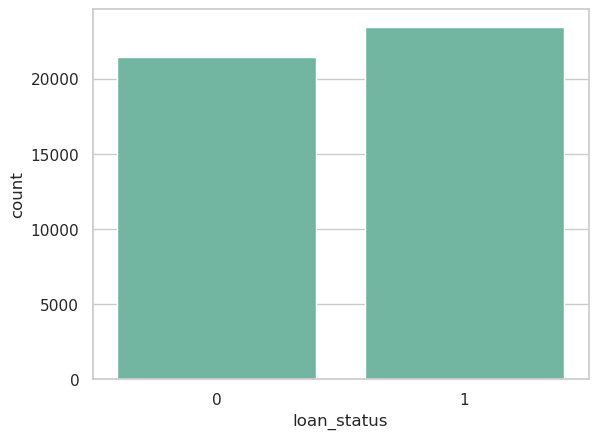

In [8]:
sns.countplot(x='loan_status', data=datam)

### Inference: 
There is a good balance of approved and rejected Loans. Since this dataset is synthetic, there are no pending loans.

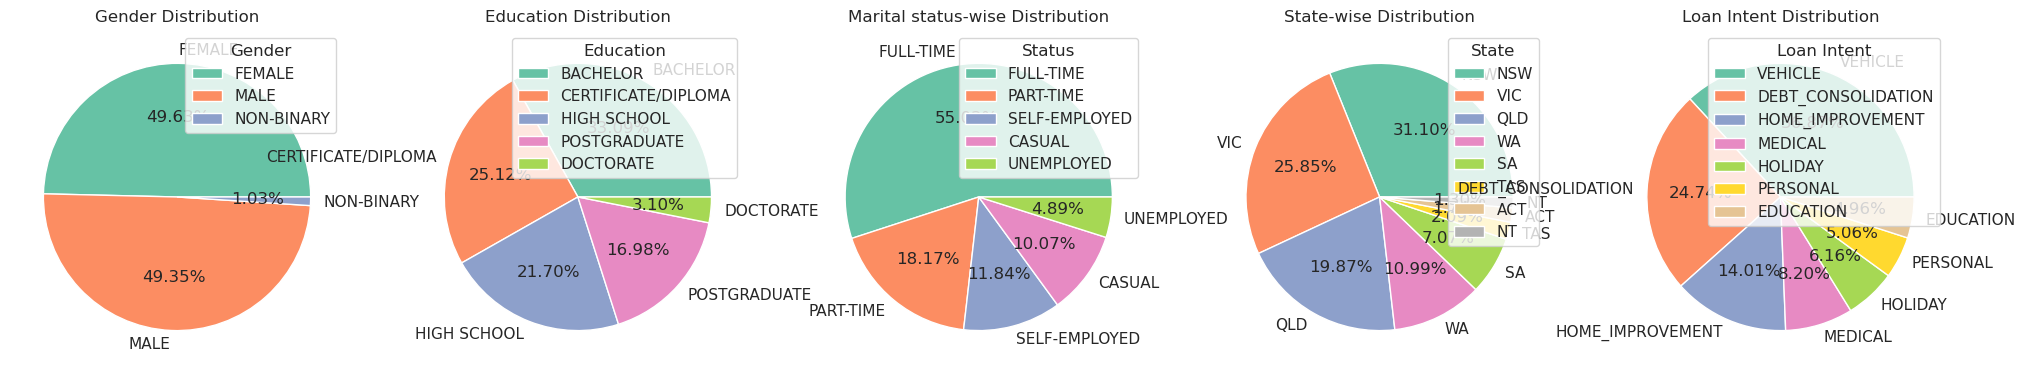

In [9]:
# demographic distribution pie charts
eda1 = datam['person_gender'].value_counts().reset_index()
eda1.columns=['gender', 'count']

eda2 = datam['person_education'].value_counts().reset_index()
eda2.columns=['education', 'count']

eda3 = datam['person_emp_status'].value_counts().reset_index()
eda3.columns=['status', 'count']

eda4 = datam['person_state'].value_counts().reset_index()
eda4.columns=['state', 'count']

eda5= datam['loan_intent'].value_counts().reset_index()
eda5.columns=['intent', 'count']

fig, axes=plt.subplots(1,5,figsize=(25,25))
axes = axes.flatten()

axes[0].pie(eda1['count'], labels=eda1['gender'], autopct='%.2f%%')
axes[0].set_title('Gender Distribution')
axes[0].legend(eda1['gender'], title="Gender", loc="upper right")

axes[1].pie(eda2['count'], labels=eda2['education'], autopct='%.2f%%')
axes[1].set_title('Education Distribution')
axes[1].legend(eda2['education'], title="Education", loc="upper right")

axes[2].pie(eda3['count'], labels=eda3['status'], autopct='%.2f%%')
axes[2].set_title('Marital status-wise Distribution')
axes[2].legend(eda3['status'], title="Status", loc="upper right")

axes[3].pie(eda4['count'], labels=eda4['state'], autopct='%.2f%%')
axes[3].set_title('State-wise Distribution')
axes[3].legend(eda4['state'], title="State", loc="upper right")

axes[4].pie(eda5['count'], labels=eda5['intent'], autopct='%.2f%%')
axes[4].set_title('Loan Intent Distribution')
axes[4].legend(eda5['intent'], title="Loan Intent", loc="upper right")

plt.show()


### Inference:
1) ALmost even split in male (49.35%) vs female (49.63%). Very small percentage of the demographic is Non-Binary (1.03%).
2) Most applicants hold a bachelor's degree (), next biggest demograohic group holds a diploma (25.12%). Only a few loan applicants hold a doctorate.
3) The more than half the applicants are employed full-time which reduces our risk of lending (55.02%). The minority of unemployed applicants (4.89%) need to be screened more thoroughly.
4) Most applicants are from New South Whales (NSW) (31.10%) and Victoria (VIC) (25.05%), which is a more affluent part of Australia
5) The biggest reason for taking a loan is for buying/upgrading Vehicles ().

| State/Territory | Full Name                    | Region Group |
| --------------- | ---------------------------- | ------------ |
| NSW             | New South Wales              | South-East   |
| VIC             | Victoria                     | South-East   |
| ACT             | Australian Capital Territory | South-East   |
| QLD             | Queensland                   | North-East   |
| NT              | Northern Territory           | North        |
| WA              | Western Australia            | West         |
| SA              | South Australia              | South        |
| TAS             | Tasmania                     | South        |


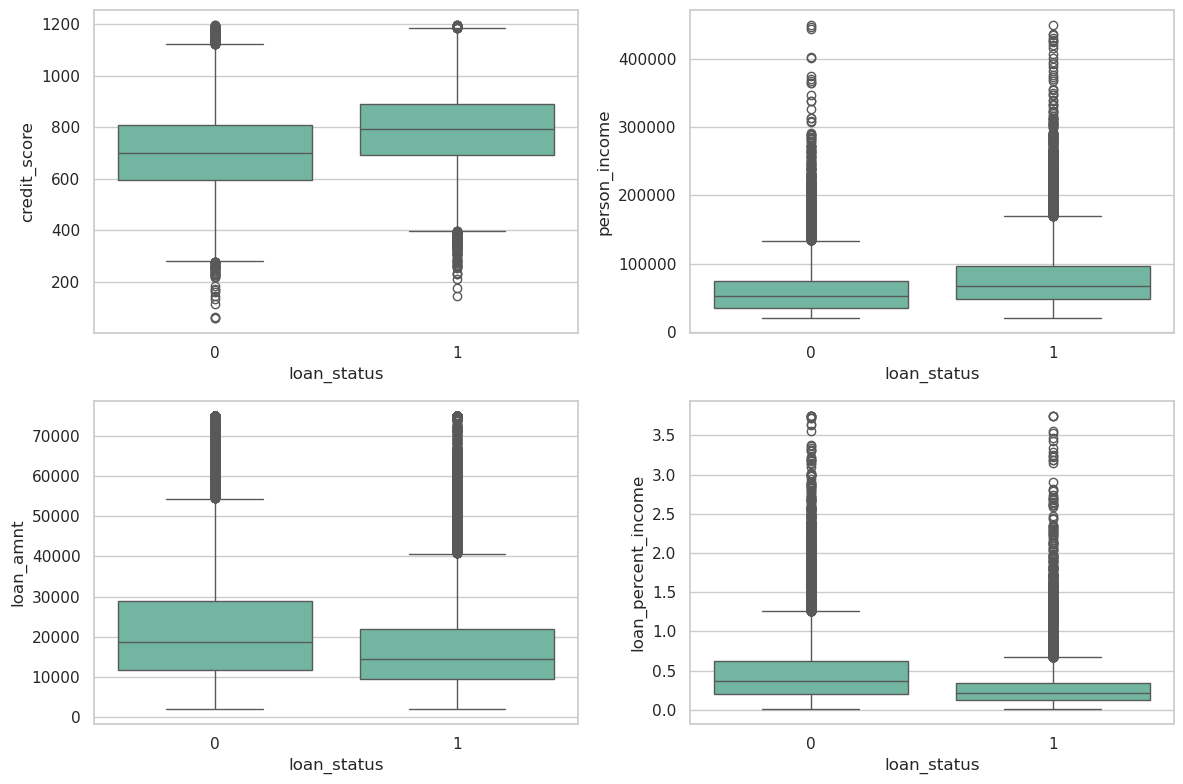

In [10]:
fig, axes = plt.subplots(2,2, figsize=(12,8))

sns.boxplot(x='loan_status', y='credit_score', data=datam, ax=axes[0,0])
sns.boxplot(x='loan_status', y='person_income', data=datam, ax=axes[0,1])
sns.boxplot(x='loan_status', y='loan_amnt', data=datam, ax=axes[1,0])
sns.boxplot(x='loan_status', y='loan_percent_income', data=datam, ax=axes[1,1])

plt.tight_layout()
plt.show()

In [11]:
from scipy.stats import zscore

num_cols = [
    'person_income',
    'loan_amnt',
    'credit_score',
    'loan_int_rate'
]

for col in num_cols:
    z = np.abs(zscore(datam[col]))
    print(f"{col}: Count = {(z > 3).sum()}, Percentage = {((z > 3).sum() / datam.shape[0]) * 100:.2f}%")

person_income: Count = 727, Percentage = 1.62%
loan_amnt: Count = 959, Percentage = 2.14%
credit_score: Count = 61, Percentage = 0.14%
loan_int_rate: Count = 67, Percentage = 0.15%


### Inference:
the percetages of outliers is very, very low. we can comfortably drop them.

In [12]:
z = np.abs(zscore(datam[num_cols]))
datam = datam[(z < 3).all(axis=1)].copy()

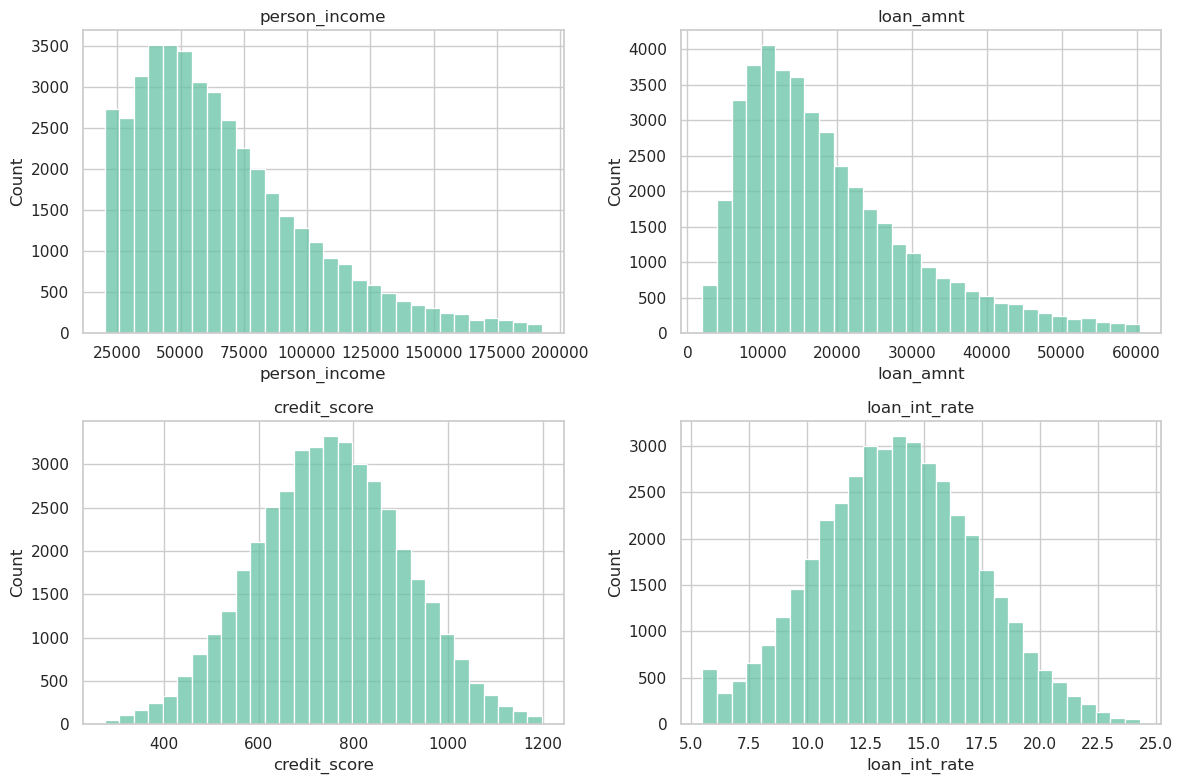

In [13]:
features = [
    'person_income',
    'loan_amnt',
    'credit_score',
    'loan_int_rate'
]

fig, axes = plt.subplots(2, 2, figsize=(12,8))

for ax, feat in zip(axes.flatten(), features):
    sns.histplot(datam[feat], ax=ax, bins=30)
    ax.set_title(feat)

plt.tight_layout()
plt.show()

## Preprocessing & Training

### Baseline:
1) If i guess everything as approved, i'd still get 54% accuracy
2) If i guess everything as rejected, I'd still get 46% accuracy

### Linear Regression Model:

In [14]:
datam['statusw'] =  datam['loan_status'].map({0: 'REJECTED', 1: 'APPROVED', 2: 'PENDING'}).copy()

In [15]:
datam[['statusw', 'loan_status']].head()

,statusw,loan_status
0,APPROVED,1
1,REJECTED,0
2,REJECTED,0
3,APPROVED,1
4,REJECTED,0


In [16]:
X = datam[model_col]
Y = datam['loan_status']

In [17]:
X.head()

,person_age,person_gender,person_education,person_state,person_income,person_emp_status,person_emp_exp,person_home_ownership,help_debt_amount,loan_amnt,loan_intent,loan_term_months,loan_int_rate,loan_percent_income,credit_history_length,credit_score,previous_loan_defaults_on_file,flag_income_loan_mismatch,flag_young_high_loan
0,39,MALE,HIGH SCHOOL,QLD,62994,FULL-TIME,9,OWN,0,7600,DEBT_CONSOLIDATION,84,8.94,0.120646,17,843,NO,0,0
1,25,MALE,CERTIFICATE/DIPLOMA,SA,77107,FULL-TIME,5,MORTGAGE,0,14100,DEBT_CONSOLIDATION,36,12.25,0.182863,6,734,NO,0,0
2,45,FEMALE,CERTIFICATE/DIPLOMA,WA,30752,PART-TIME,21,RENT,0,36000,VEHICLE,12,18.35,1.170656,24,732,NO,1,0
3,38,MALE,BACHELOR,VIC,84232,FULL-TIME,5,FAMILY,7185,53000,PERSONAL,60,11.10,0.629215,16,969,NO,1,0
4,75,MALE,BACHELOR,NSW,141352,PART-TIME,1,MORTGAGE,0,17000,HOME_IMPROVEMENT,60,23.63,0.120267,57,845,YES,0,0


In [18]:
Y.head()

0    1
1    0
2    0
3    1
4    0
Name: loan_status, dtype: int64

In [19]:
#encoding the categorical features
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.25, random_state = 42, stratify=Y)

In [20]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 43094 entries, 0 to 44887
Data columns (total 40 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   person_age                            43094 non-null  int64  
 1   person_income                         43094 non-null  int64  
 2   person_emp_exp                        43094 non-null  int64  
 3   help_debt_amount                      43094 non-null  int64  
 4   loan_amnt                             43094 non-null  int64  
 5   loan_term_months                      43094 non-null  int64  
 6   loan_int_rate                         43094 non-null  float64
 7   loan_percent_income                   43094 non-null  float64
 8   credit_history_length                 43094 non-null  int64  
 9   credit_score                          43094 non-null  int64  
 10  flag_income_loan_mismatch             43094 non-null  int64  
 11  flag_young_high_loan

In [21]:
print(f'Dataset: {len(datam)} samples, {X.shape[1]} features, {Y.nunique()} classes')
print(f'Train: {len(X_train)} samples')
print(f'Test: {len(X_test)} samples')

Dataset: 43094 samples, 40 features, 2 classes
Train: 32320 samples
Test: 10774 samples


In [22]:
num_cols = [
    'person_age',
    'person_income',
    'person_emp_exp',
    'help_debt_amount',
    'loan_amnt',
    'loan_term_months',
    'loan_int_rate',
    'loan_percent_income',
    'credit_history_length',
    'credit_score'
]

In [23]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [24]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [25]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(model, X_train, Y_train, cv = cv, scoring='accuracy')
print(f'The Model CV acc is {score.mean()*100:.2f} +- {score.std()*100:.2f}%')

The Model CV acc is 70.10 +- 0.42%


### Inference:
The model hasn't blindly guessed but it has learnt some pattern because the prediction score is higher than the baseline atleast.

In [26]:
Y_pred = model.predict(X_test)

In [27]:
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.70      0.64      0.67      5125
           1       0.70      0.75      0.73      5649

    accuracy                           0.70     10774
   macro avg       0.70      0.70      0.70     10774
weighted avg       0.70      0.70      0.70     10774



### Inference:
it might be better to use another model.

### Decision Tree

In [28]:
model_2 = DecisionTreeClassifier(max_depth=5,random_state=42)
model_2.fit(X_train, Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
score = cross_val_score(model_2, X_train, Y_train, cv = cv, scoring='accuracy')
print(f'The Model CV acc is {score.mean()*100:.2f} +- {score.std()*100:.2f}%')

The Model CV acc is 69.68 +- 0.22%


In [30]:
Y_pred_2 = model_2.predict(X_test)

In [31]:
print(classification_report(Y_test, Y_pred_2))

              precision    recall  f1-score   support

           0       0.67      0.71      0.69      5125
           1       0.72      0.69      0.70      5649

    accuracy                           0.70     10774
   macro avg       0.70      0.70      0.70     10774
weighted avg       0.70      0.70      0.70     10774



### Inference
well shit.   
accuracy didn't change appreciably. switch to another model or maybe the data is lacking...

### Random Forest

In [32]:
model_3 = RandomForestClassifier(n_estimators=100, random_state=42)
model_3.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
score = cross_val_score(model_3, X_train, Y_train, cv = cv, scoring='accuracy')
print(f'The Model CV acc is {score.mean()*100:.2f} +- {score.std()*100:.2f}%')

The Model CV acc is 69.60 +- 0.17%


In [34]:
model_3.score(X_train,Y_train)
model_3.score(X_test, Y_test)

0.7039168368294041

In [35]:
Y.value_counts(normalize=True)

loan_status
1    0.524296
0    0.475704
Name: proportion, dtype: float64

In [36]:
'loan_status' in X.columns

False

In [37]:
X.shape

(43094, 40)